# 🚗 Car Price Prediction with Machine Learning
### Oasis Infobyte Data Science Internship — Task 3
**Name:** Sadiya Anmol  
**Track:** Data Science  
**Dataset:** CAR DETAILS FROM CAR DEKHO

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('screenshots', exist_ok=True)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 1. Load Dataset & Initial Inspection

In [2]:
# Load dataset
df = pd.read_csv('Downloads/CAR DETAILS FROM CAR DEKHO.csv')

print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (4340, 8)

Column Names: ['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']

First 5 rows:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


## 2. Data Cleaning

In [3]:
# Check data types
print("Data Types:")
print(df.dtypes)
print("\nNull Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nDescriptive Statistics:")
df.describe()

Data Types:
name             object
year              int64
selling_price     int64
km_driven         int64
fuel             object
seller_type      object
transmission     object
owner            object
dtype: object

Null Values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Duplicate Rows: 763

Descriptive Statistics:


,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [4]:
# Remove duplicates
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Removed {before - after} duplicate rows")
print(f"Dataset size after cleaning: {df.shape}")

# Check unique values in categorical columns
print("\nFuel Types:", df['fuel'].unique())
print("Transmission:", df['transmission'].unique())
print("Seller Type:", df['seller_type'].unique())
print("Owner:", df['owner'].unique())

Removed 763 duplicate rows
Dataset size after cleaning: (3577, 8)

Fuel Types: ['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']
Transmission: ['Manual' 'Automatic']
Seller Type: ['Individual' 'Dealer' 'Trustmark Dealer']
Owner: ['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car']


## 3. Feature Engineering
Creating new features to improve model performance:
- **Car Age** = Current Year - Year of Purchase
- **Brand** = First word extracted from car name

In [18]:
# Calculate car age
df['car_age'] = 2026- df['year']

# Extract brand from car name
df['brand'] = df['name'].apply(lambda x: x.split()[0])

print("New features added!")
print("\nCar Age sample:")
print(df[['name', 'year', 'car_age']].head())
print("\nBrand sample:")
print(df[['name', 'brand']].head())
print("\nTop 10 Brands:")
print(df['brand'].value_counts().head(10))

New features added!

Car Age sample:
                       name  year  car_age
0             Maruti 800 AC  2007       19
1  Maruti Wagon R LXI Minor  2007       19
2      Hyundai Verna 1.6 SX  2012       14
3    Datsun RediGO T Option  2017        9
4     Honda Amaze VX i-DTEC  2014       12

Brand sample:
                       name    brand
0             Maruti 800 AC   Maruti
1  Maruti Wagon R LXI Minor   Maruti
2      Hyundai Verna 1.6 SX  Hyundai
3    Datsun RediGO T Option   Datsun
4     Honda Amaze VX i-DTEC    Honda

Top 10 Brands:
brand
Maruti        1072
Hyundai        637
Mahindra       328
Tata           308
Ford           220
Honda          216
Toyota         170
Chevrolet      151
Renault        110
Volkswagen      93
Name: count, dtype: int64


## 4. Exploratory Data Analysis (EDA)

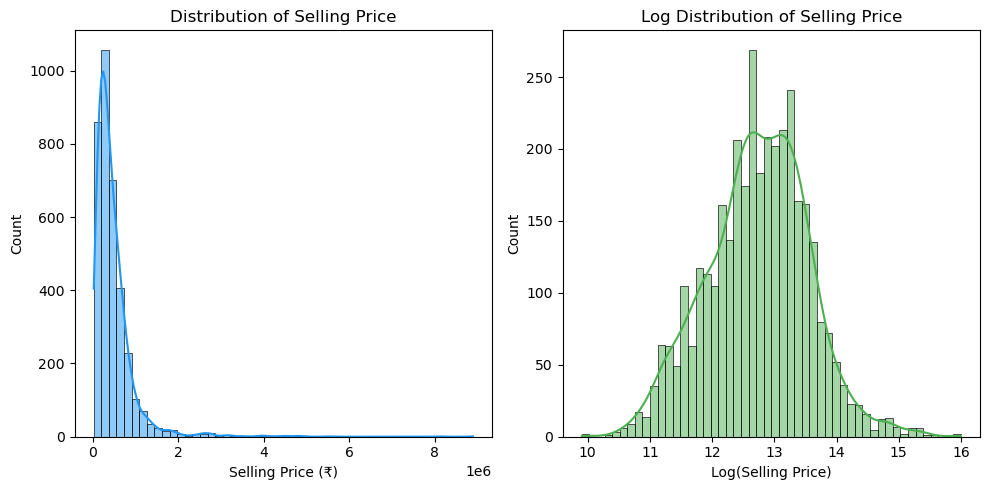

✅ Most cars are priced between ₹2-10 Lakhs


In [6]:
# Distribution of selling prices
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(df['selling_price'], bins=50, color='#2196F3', kde=True)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price (₹)')
plt.ylabel('Count')

plt.subplot(1,2,2)
sns.histplot(np.log1p(df['selling_price']), bins=50, color='#4CAF50', kde=True)
plt.title('Log Distribution of Selling Price')
plt.xlabel('Log(Selling Price)')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('screenshots/price_distribution.png', bbox_inches='tight')
plt.show()
print("✅ Most cars are priced between ₹2-10 Lakhs")

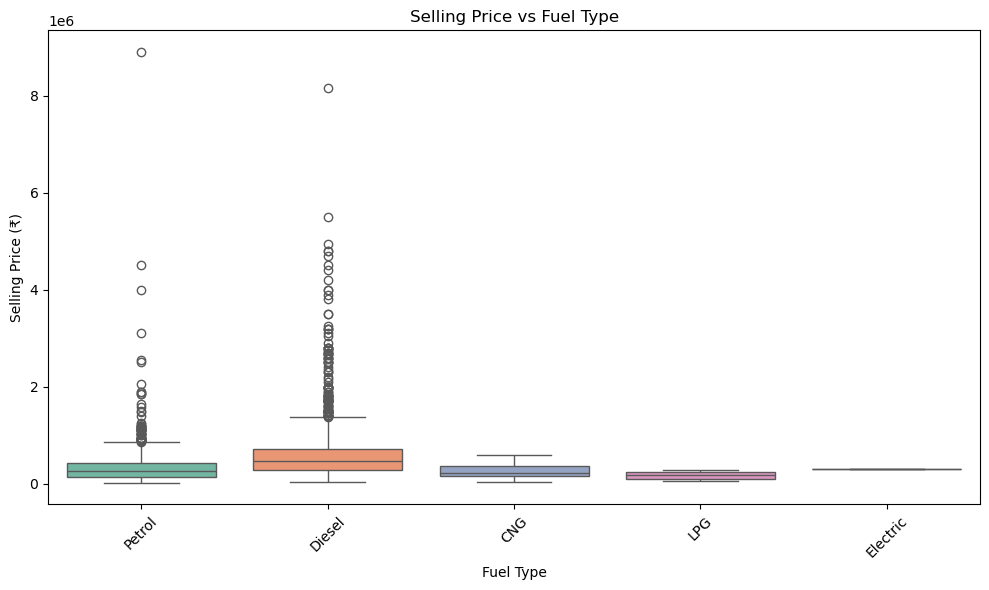

In [7]:
# Box plot: Price vs Fuel Type
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='fuel', y='selling_price', palette='Set2')
plt.title('Selling Price vs Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('screenshots/price_vs_fuel.png', bbox_inches='tight')
plt.show()

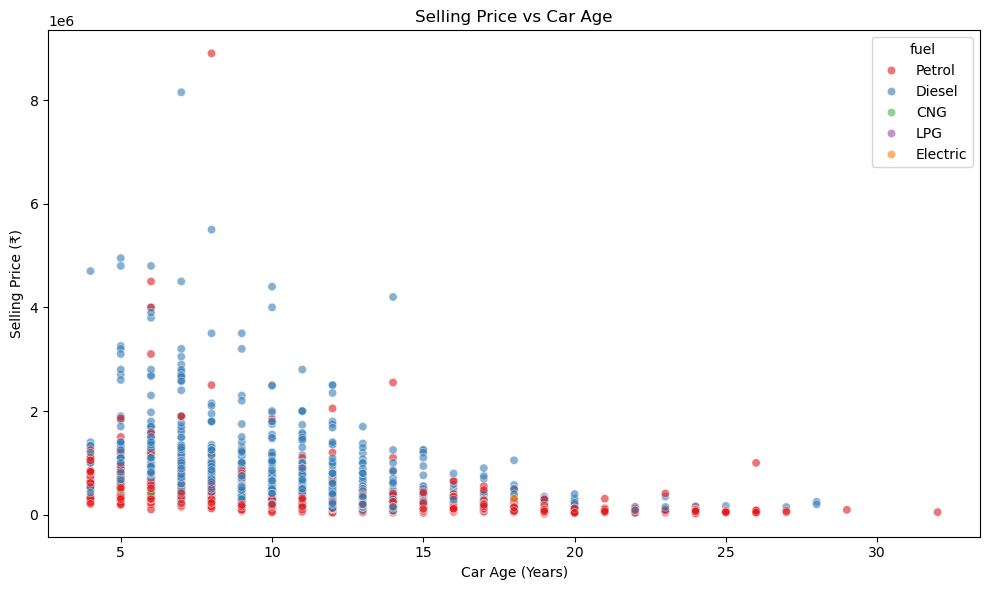

✅ Newer cars have higher selling prices as expected!


In [8]:
# Scatter plot: Price vs Car Age
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='car_age', y='selling_price',
                hue='fuel', palette='Set1', alpha=0.6)
plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price (₹)')
plt.tight_layout()
plt.savefig('screenshots/price_vs_age.png', bbox_inches='tight')
plt.show()
print("✅ Newer cars have higher selling prices as expected!")

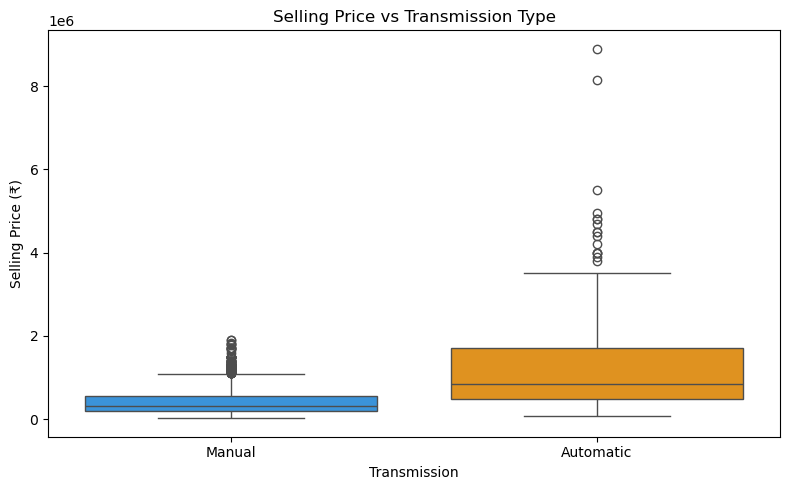

✅ Automatic cars have higher selling prices than Manual!


In [9]:
# Box plot: Price vs Transmission
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='transmission', y='selling_price',
            palette=['#2196F3','#FF9800'])
plt.title('Selling Price vs Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Selling Price (₹)')
plt.tight_layout()
plt.savefig('screenshots/price_vs_transmission.png', bbox_inches='tight')
plt.show()
print("✅ Automatic cars have higher selling prices than Manual!")

## 5. Encoding Categorical Variables
Converting text categories to numbers for ML models

In [10]:
# Label Encoding for categorical columns
le = LabelEncoder()

df_encoded = df.copy()

# Encode categorical columns
categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner', 'brand']
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Drop columns we don't need
df_encoded = df_encoded.drop(['name', 'year'], axis=1)

print("✅ Encoding complete!")
print("\nEncoded dataset shape:", df_encoded.shape)
print("\nFirst 5 rows:")
df_encoded.head()

✅ Encoding complete!

Encoded dataset shape: (3577, 8)

First 5 rows:


,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age,brand
0,60000,70000,4,1,1,0,17,18
1,135000,50000,4,1,1,0,17,18
2,600000,100000,1,1,1,0,12,10
3,250000,46000,4,1,1,0,7,5
4,450000,141000,1,1,1,2,10,9


## 6. Feature Correlation Heatmap

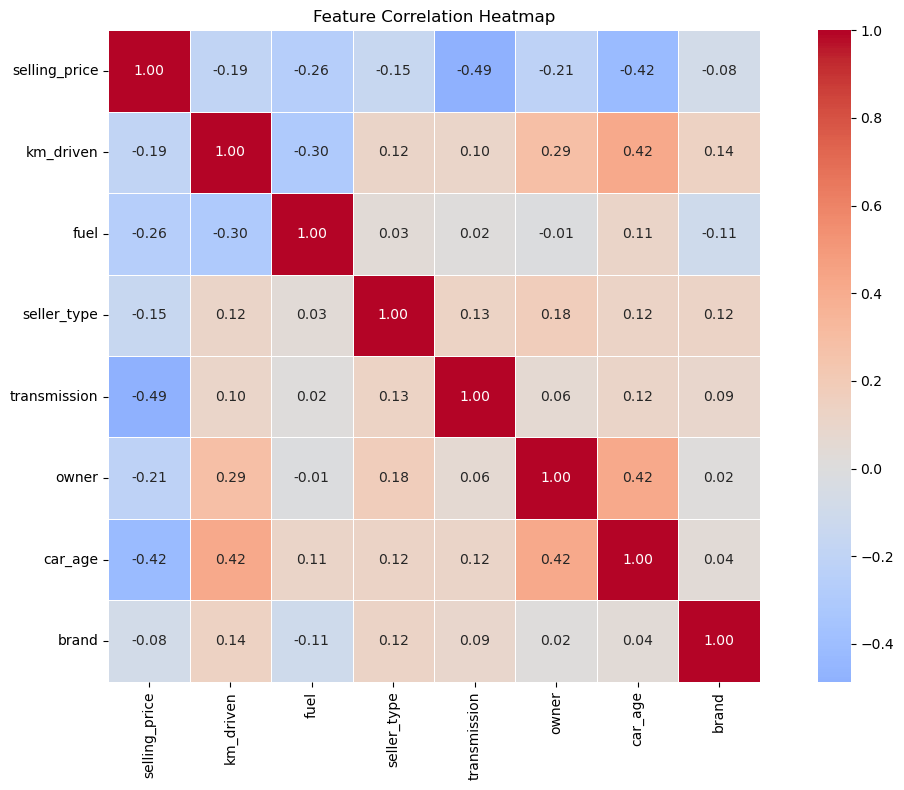

✅ Present_Price and car_age are most correlated with Selling Price!


In [11]:
# Correlation heatmap
plt.figure(figsize=(12,8))
correlation = df_encoded.corr()
sns.heatmap(correlation, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('screenshots/correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("✅ Present_Price and car_age are most correlated with Selling Price!")

## 7. Model Training

In [12]:
# Define features and target
X = df_encoded.drop('selling_price', axis=1)
y = df_encoded['selling_price']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Features used: {X.columns.tolist()}")

Training samples: 2861
Testing samples: 716
Features used: ['km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'car_age', 'brand']


In [13]:
# Train 3 models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    print(f"\n{'='*45}")
    print(f"Model: {name}")
    print(f"MAE:  ₹{mae:,.2f}")
    print(f"RMSE: ₹{rmse:,.2f}")
    print(f"R²:   {r2:.4f} ({r2*100:.2f}%)")


Model: Linear Regression
MAE:  ₹214,459.00
RMSE: ₹444,901.43
R²:   0.3855 (38.55%)

Model: Random Forest
MAE:  ₹167,745.03
RMSE: ₹410,066.65
R²:   0.4780 (47.80%)

Model: Gradient Boosting
MAE:  ₹160,051.49
RMSE: ₹391,997.72
R²:   0.5230 (52.30%)


## 8. Model Evaluation & Comparison

In [14]:
# Results comparison table
results_df = pd.DataFrame(results).T
print("Model Comparison:")
print(results_df.round(2))

Model Comparison:
                         MAE       RMSE    R²
Linear Regression  214459.00  444901.43  0.39
Random Forest      167745.03  410066.65  0.48
Gradient Boosting  160051.49  391997.72  0.52


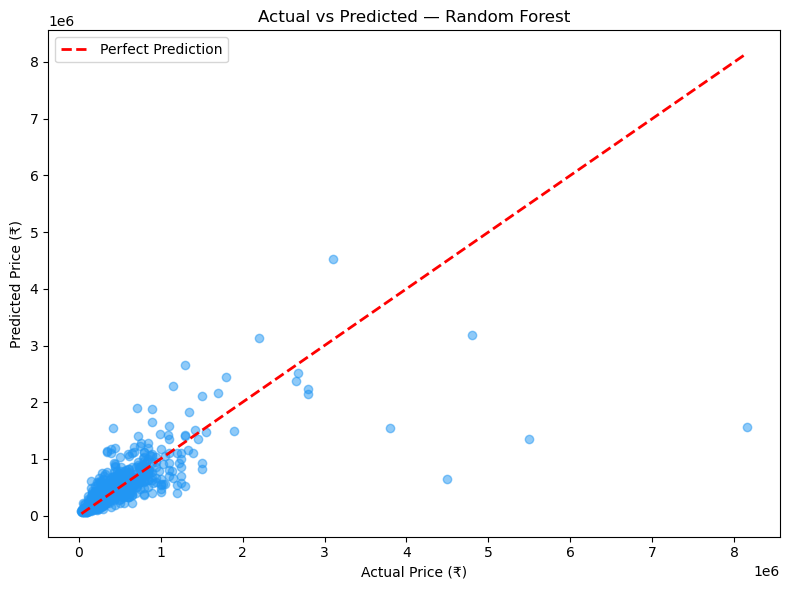

In [15]:
# Actual vs Predicted scatter plot for best model
best_model = models['Random Forest']
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='#2196F3')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price (₹)')
plt.ylabel('Predicted Price (₹)')
plt.title('Actual vs Predicted — Random Forest')
plt.legend()
plt.tight_layout()
plt.savefig('screenshots/actual_vs_predicted.png', bbox_inches='tight')
plt.show()

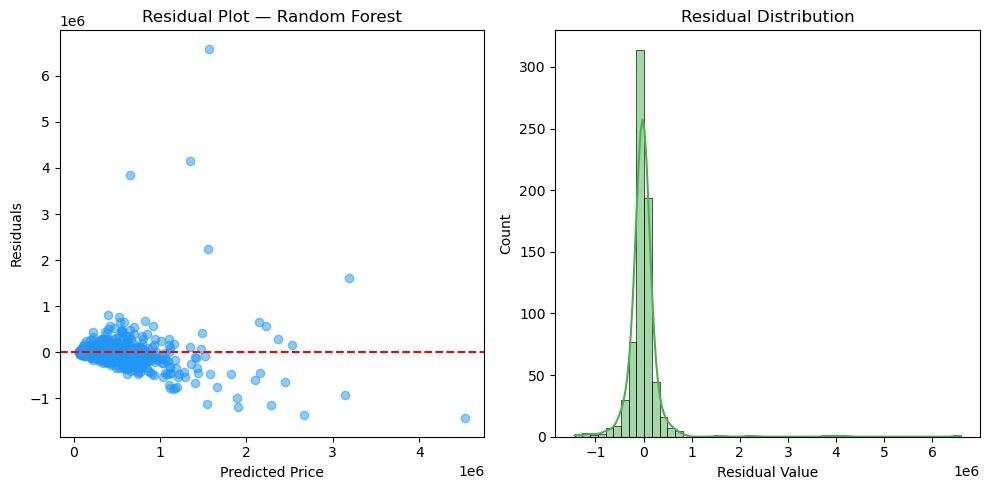

✅ Residuals are randomly distributed — good sign!


In [19]:
# Residual Plot
y_pred_rf = models['Random Forest'].predict(X_test)
residuals = y_test - y_pred_rf

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(y_pred_rf, residuals, alpha=0.5, color='#2196F3')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot — Random Forest')

plt.subplot(1,2,2)
sns.histplot(residuals, bins=50, kde=True, color='#4CAF50')
plt.xlabel('Residual Value')
plt.title('Residual Distribution')
plt.tight_layout()
plt.savefig('screenshots/residual_plot.png', bbox_inches='tight')
plt.show()
print("✅ Residuals are randomly distributed — good sign!")

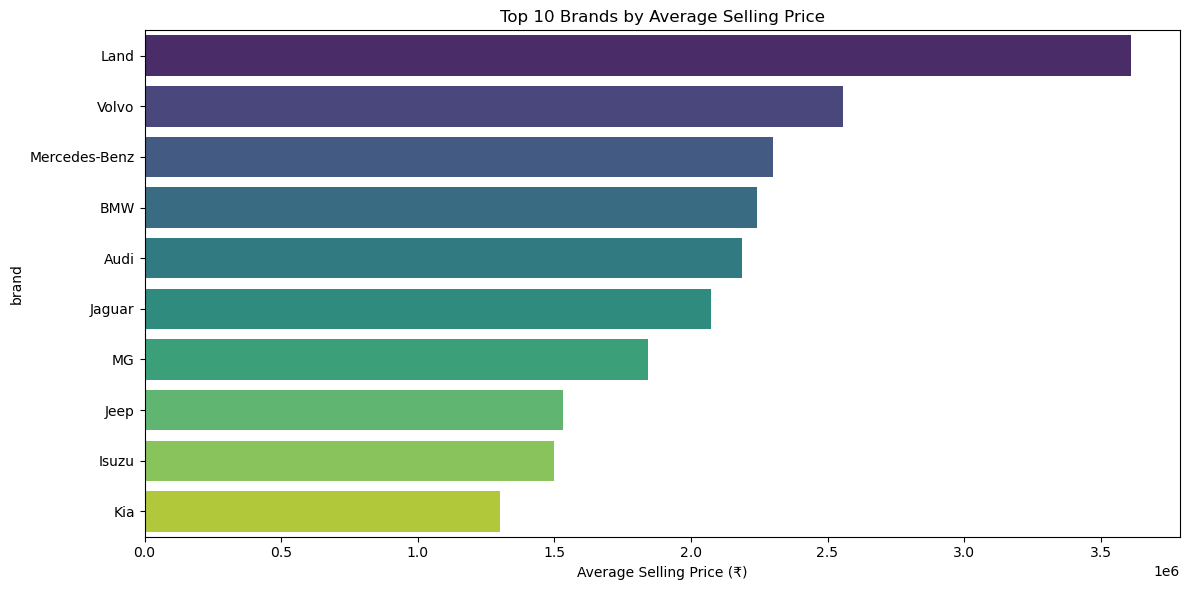

In [20]:
# Top brands by average selling price
plt.figure(figsize=(12,6))
brand_price = df.groupby('brand')['selling_price'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=brand_price.values, y=brand_price.index, palette='viridis')
plt.title('Top 10 Brands by Average Selling Price')
plt.xlabel('Average Selling Price (₹)')
plt.tight_layout()
plt.savefig('screenshots/brand_price.png', bbox_inches='tight')
plt.show()

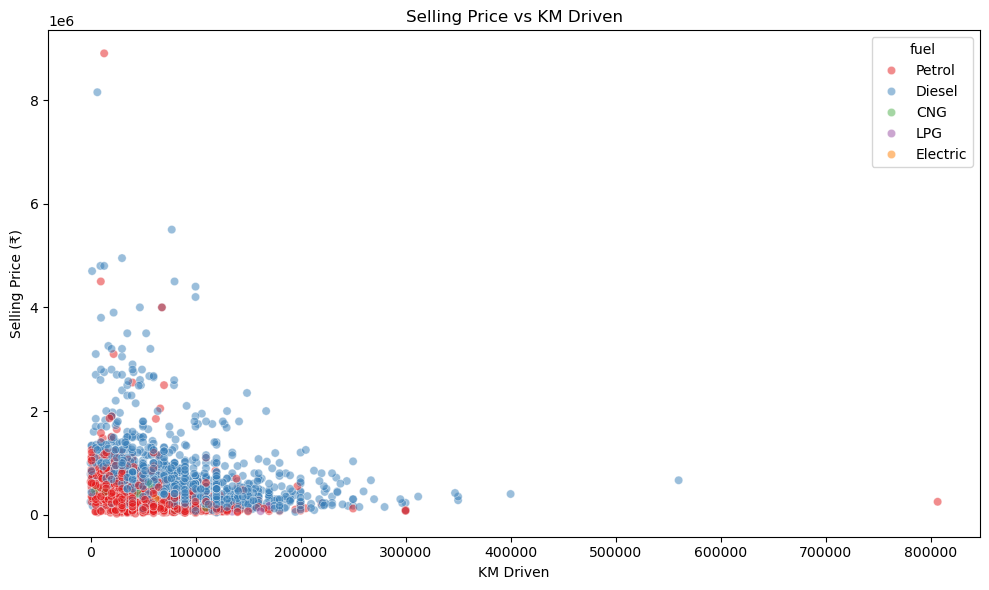

✅ Higher km driven = lower selling price as expected!


In [21]:
# Scatter: Price vs KM Driven
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='km_driven', y='selling_price',
                hue='fuel', palette='Set1', alpha=0.5)
plt.title('Selling Price vs KM Driven')
plt.xlabel('KM Driven')
plt.ylabel('Selling Price (₹)')
plt.tight_layout()
plt.savefig('screenshots/price_vs_km.png', bbox_inches='tight')
plt.show()
print("✅ Higher km driven = lower selling price as expected!")

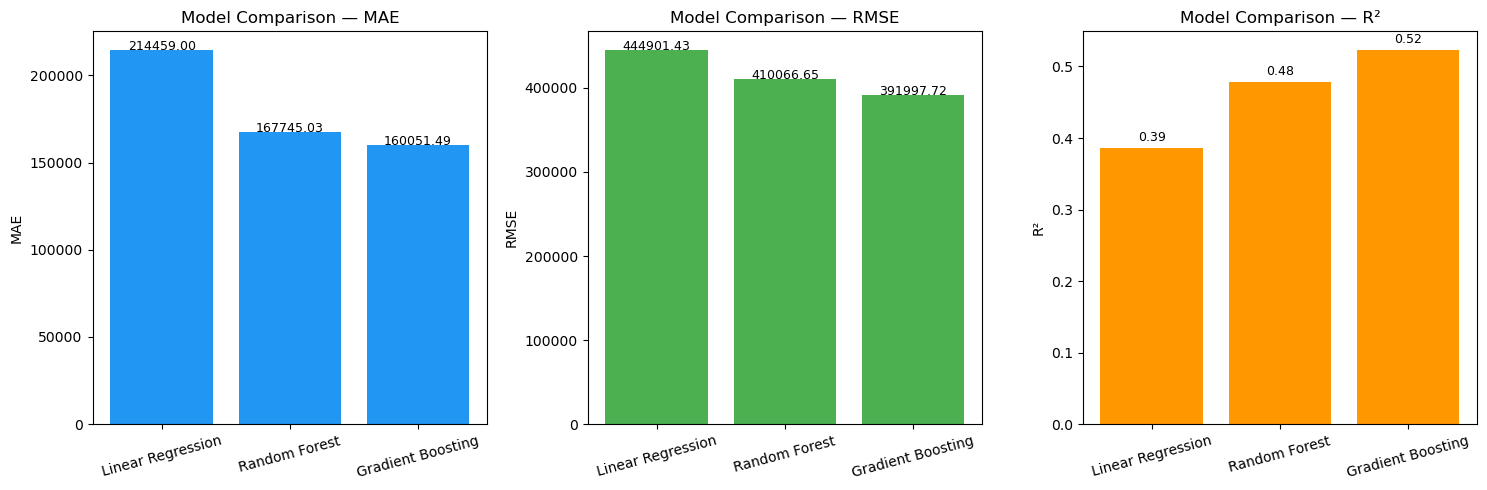

In [16]:
# Bar chart comparing models
fig, axes = plt.subplots(1, 3, figsize=(15,5))

metrics = ['MAE', 'RMSE', 'R²']
colors = ['#2196F3', '#4CAF50', '#FF9800']

for i, metric in enumerate(metrics):
    values = [results[m][metric] for m in results]
    bars = axes[i].bar(results.keys(), values, color=colors[i])
    axes[i].set_title(f'Model Comparison — {metric}')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f'{val:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('screenshots/model_comparison.png', bbox_inches='tight')
plt.show()

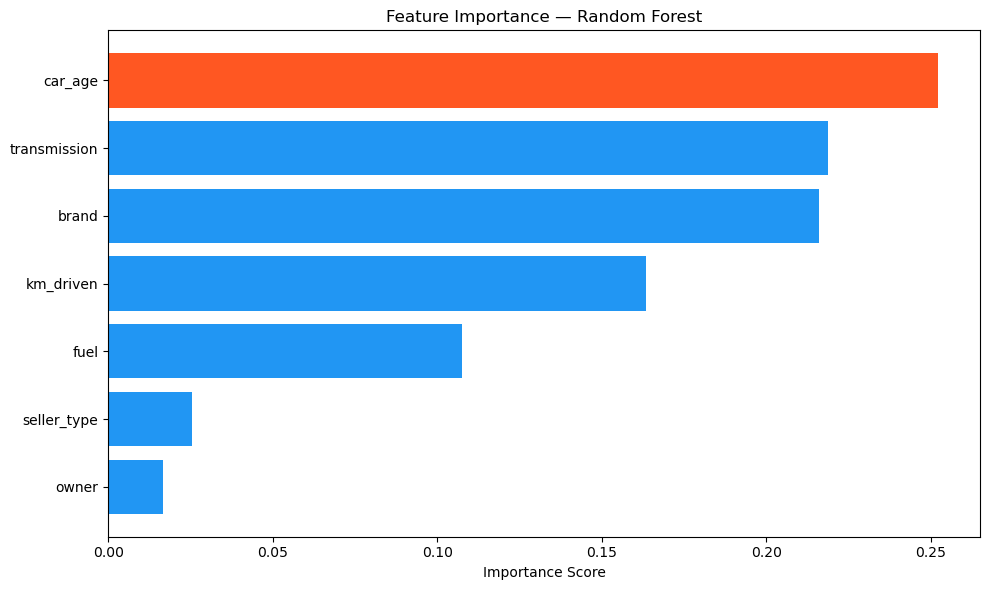

In [17]:
# Feature importance for Random Forest
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10,6))
colors = ['#2196F3' if x < max(feature_importance['Importance'])
          else '#FF5722' for x in feature_importance['Importance']]
plt.barh(feature_importance['Feature'],
         feature_importance['Importance'],
         color=colors)
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('screenshots/feature_importance.png', bbox_inches='tight')
plt.show()

## 9. Conclusion

**Best Model: Random Forest Regressor**

**Why Random Forest?**
- Highest R² score — explains most variance in price
- Lowest MAE and RMSE — closest predictions
- Handles non-linear relationships well
- Not affected by outliers like Linear Regression

**Key Findings:**
- Car age and km_driven negatively affect price
- Automatic transmission cars sell for more
- Diesel cars generally have higher resale value
- Brand significantly impacts resale price

**Feature Importance:**
- km_driven and car_age are most important features
- Transmission type also plays a significant role
- Fuel type impacts price but less than age/km

**Real World Use:**
This model can be used by:
- 🚗 Car dealerships to price used cars
- 👤 Individual sellers to estimate fair price
- 🏦 Banks for vehicle loan assessment